In [4]:
# # DOWNLOAD

# !pip install gensim
# !pip install spacy
# !python -m spacy download en_core_web_sm
# !pip install bertopic sentence-transformers umap-learn hdbscan

In [110]:
# INIT

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy
nlp = spacy.load("en_core_web_sm")

#

from google.colab import drive
drive.mount('/content/drive')

from scipy.stats import linregress

from sklearn.feature_extraction import text
from sklearn.linear_model import LinearRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

custom_stopwords = ['system','security','propose','approach','study','model','paper']

n = 6

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [141]:
# FUNCTION

def clean_dataset(df, min_words=50, remove_proceedings=True):
    """
    Documents containing fewer than 50 words were removed to
    avoid sparse topic distributions and improve model stability,
    following standard text preprocessing practices in topic modeling research
    (Blei et al., 2003; Jurafsky & Martin, 2023)


    Cleansing dataset for LDA / topic modeling

    Parameters:
    - df : pandas DataFrame
    - min_words : minimum number of words in abstract
    - remove_proceedings : whether to remove titles containing 'Proceedings'

    Returns:
    - cleaned DataFrame
    """

    # Keep relevant columns
    df = df[['Title', 'Year', 'Abstract']].copy()

    # Drop missing abstract
    df = df.dropna(subset=['Abstract'])

    # Remove proceedings summary
    if remove_proceedings:
        df = df[~df['Title'].str.contains("Proceedings", case=False, na=False)]

    # Remove short abstracts
    df['word_count'] = df['Abstract'].apply(lambda x: len(str(x).split()))
    df = df[df['word_count'] > min_words]

    # Remove duplicates
    df = df.drop_duplicates(subset=['Title', 'Abstract'])

    # Remove non-English abstracts (optional)
    # df = df[df['Abstract'].str.len() > 0]

    # Drop helper column
    df = df.drop(columns=['word_count'])

    print("Jumlah setelah cleaning:", len(df))

    return df


def preprocess(text):
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
        if token.is_stop == False and token.is_punct == False:
            if token.pos_ in ['NOUN','VERB','ADJ']:
                tokens.append(token.lemma_)
    return " ".join(tokens)


def run_lda(
    df,
    text_column='clean_text',
    n_topics=6,
    min_df=5,
    max_df=0.85,
    custom_stopwords=None,
    random_state=42
):
    from sklearn.feature_extraction import text

    stop_words = text.ENGLISH_STOP_WORDS

    if custom_stopwords:
        stop_words = list(stop_words.union(custom_stopwords))

    vectorizer = CountVectorizer(
        max_df=max_df,
        min_df=min_df,
        stop_words=stop_words
    )

    count_matrix = vectorizer.fit_transform(df[text_column])

    lda_model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=random_state
    )

    document_topic_matrix = lda_model.fit_transform(count_matrix)

    return lda_model, vectorizer, document_topic_matrix, count_matrix


def print_top_words(lda_model, vectorizer, n_top_words=10):
    feature_names = vectorizer.get_feature_names_out()

    for topic_idx, topic in enumerate(lda_model.components_):
        top_words = [feature_names[i]
                     for i in topic.argsort()[:-n_top_words - 1:-1]]

        print(f"Topic {topic_idx}: {' | '.join(top_words)}")


import pandas as pd
import matplotlib.pyplot as plt

def plot_topic_evolution(
    lda_model,
    count_matrix,
    df,
    year_column='Year',
    label_mode='last',  # 'last' atau 'peak'
    title="Topic Evolution Over Time",
    save_csv=False,
    csv_name="topic_evolution_raw.csv"
):
    """
    Plot topic evolution over time and optionally export raw data.

    Parameters:
    - lda_model : trained LDA model
    - count_matrix : vectorized matrix
    - df : original dataframe
    - year_column : column name for year
    - label_mode : 'last' or 'peak'
    - save_csv : export raw data or not
    """

    # Transform topic distribution
    topic_distribution = lda_model.transform(count_matrix)

    df_topics = pd.DataFrame(topic_distribution)
    df_topics[year_column] = df[year_column].values

    # Group by year
    year_topic = df_topics.groupby(year_column).mean()

    # Plot
    plt.figure(figsize=(12,6))

    for i in range(lda_model.n_components):
        plt.plot(year_topic.index,
                 year_topic[i],
                 marker='o',
                 linewidth=2,
                 label=f"Topic {i+1}")

        if label_mode == 'last':
            x_val = year_topic.index[-1]
            y_val = year_topic[i].iloc[-1]
        elif label_mode == 'peak':
            x_val = year_topic[i].idxmax()
            y_val = year_topic[i].max()
        else:
            continue

        plt.text(x_val,
                 y_val,
                 f"{y_val:.2f}",
                 fontsize=9)

    plt.legend()
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel("Average Topic Proportion")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Export raw if needed
    if save_csv:
        df_export = year_topic.reset_index()
        df_export.columns = [year_column] + [f"Topic_{i+1}" for i in range(lda_model.n_components)]
        df_export.to_csv(csv_name, index=False)
        print(f"Raw data saved to {csv_name}")

    return year_topic


def calculate_agr(year_topic):
    """
    Calculate Average Growth Rate (AGR) for each topic.

    Parameters:
    - year_topic : DataFrame hasil groupby year (topic evolution)

    Returns:
    - DataFrame AGR per topic
    """

    agr_results = {}
    years = year_topic.index

    for col in year_topic.columns:
        first_value = year_topic[col].iloc[0]
        last_value = year_topic[col].iloc[-1]
        n_years = len(years)

        agr = (last_value - first_value) / (n_years - 1)
        agr_results[col] = agr

    df_agr = pd.DataFrame.from_dict(agr_results, orient='index', columns=['AGR'])
    return df_agr


def calculate_agr_percent(year_topic):
    agr_results = {}
    years = year_topic.index

    for col in year_topic.columns:
        first_value = year_topic[col].iloc[0]
        last_value = year_topic[col].iloc[-1]
        n_years = len(years)

        if first_value != 0:
            agr = ((last_value - first_value) / first_value) / (n_years - 1)
        else:
            agr = None

        agr_results[col] = agr

    df_agr = pd.DataFrame.from_dict(agr_results, orient='index', columns=['AGR_percent'])
    return df_agr


def topic_trend_summary(year_topic):
    summary = []

    for col in year_topic.columns:
        first = year_topic[col].iloc[0]
        last = year_topic[col].iloc[-1]
        peak_year = year_topic[col].idxmax()
        peak_value = year_topic[col].max()

        agr = (last - first) / (len(year_topic.index) - 1)

        summary.append({
            "Topic": col,
            "First_Value": first,
            "Last_Value": last,
            "AGR": agr,
            "Peak_Year": peak_year,
            "Peak_Value": peak_value
        })

    return pd.DataFrame(summary)


def run_bertopic_pipeline(
    df,
    text_column="clean_text",
    year_column="Year",
    embedding_model_name="all-MiniLM-L6-v2",
    coherence_type="c_v"
):
    """
    Full BERTopic pipeline:
    - Train model
    - Compute coherence
    - Compute yearly topic distribution

    Returns:
    - topic_model
    - df_with_topics
    - yearly_normalized
    - coherence_score
    """

    documents = df[text_column].tolist()

    # Embeddings
    model = SentenceTransformer(embedding_model_name)
    embeddings = model.encode(documents, show_progress_bar=True)

    # Train BERTopic
    topic_model = BERTopic(language="english", calculate_probabilities=True)
    topics, probs = topic_model.fit_transform(documents, embeddings)

    df_copy = df.copy()
    df_copy["bertopic_topic"] = topics

    # Remove outliers (-1)
    df_copy = df_copy[df_copy["bertopic_topic"] != -1]

    # Coherence calculation
    tokenized_docs = [doc.split() for doc in documents]
    dictionary = Dictionary(tokenized_docs)

    topic_words = []
    for topic_id in topic_model.get_topics().keys():
        if topic_id != -1:
            words = [word for word, _ in topic_model.get_topic(topic_id)]
            topic_words.append(words)

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence=coherence_type
    )

    coherence_score = coherence_model.get_coherence()

    # Yearly normalized distribution
    yearly_distribution = (
        df_copy.groupby([year_column, "bertopic_topic"])
        .size()
        .unstack(fill_value=0)
    )

    yearly_norm = yearly_distribution.div(
        yearly_distribution.sum(axis=1),
        axis=0
    )

    return topic_model, df_copy, yearly_norm, coherence_score


def run_bertopic_pipeline_with_n(
    df,
    text_column="clean_text",
    year_column="Year",
    embedding_model_name="all-MiniLM-L6-v2",
    coherence_type="c_v",
    n_topics=6
):

    documents = df[text_column].tolist()

    # Embeddings
    model = SentenceTransformer(embedding_model_name)
    embeddings = model.encode(documents, show_progress_bar=True)

    # 🔥 Force number of topics
    topic_model = BERTopic(
        language="english",
        calculate_probabilities=True,
        nr_topics=n_topics   # <<< INI KUNCINYA
    )

    topics, probs = topic_model.fit_transform(documents, embeddings)

    df_copy = df.copy()
    df_copy["bertopic_topic"] = topics

    # Remove outlier
    df_copy = df_copy[df_copy["bertopic_topic"] != -1]

    # ---- Coherence ----
    tokenized_docs = [doc.split() for doc in documents]
    dictionary = Dictionary(tokenized_docs)

    topic_words = []
    for topic_id in topic_model.get_topics().keys():
        if topic_id != -1:
            words = [word for word, _ in topic_model.get_topic(topic_id)]
            topic_words.append(words)

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence=coherence_type
    )

    coherence_score = coherence_model.get_coherence()

    # ---- Yearly normalized ----
    yearly_distribution = (
        df_copy.groupby([year_column, "bertopic_topic"])
        .size()
        .unstack(fill_value=0)
    )

    yearly_norm = yearly_distribution.div(
        yearly_distribution.sum(axis=1),
        axis=0
    )

    return topic_model, df_copy, yearly_norm, coherence_score


def compute_topic_trends(yearly_norm):
    """
    Compute growth slope + statistical significance per topic
    """

    trend_results = []

    for topic in yearly_norm.columns:
        X = yearly_norm.index.values.reshape(-1, 1)
        y = yearly_norm[topic].values

        # Linear Regression slope
        reg = LinearRegression()
        reg.fit(X, y)
        slope = reg.coef_[0]

        # Statistical significance
        slope2, intercept, r_value, p_value, std_err = linregress(
            yearly_norm.index,
            yearly_norm[topic]
        )

        trend_results.append({
            "Topic": topic,
            "Slope": slope,
            "R_squared": r_value**2,
            "p_value": p_value
        })

    return pd.DataFrame(trend_results)


def plot_bertopic_evolution(yearly_norm, title="BERTopic Evolution", label_mode="peak"):

    plt.figure(figsize=(12,6))

    for topic in yearly_norm.columns:
        plt.plot(
            yearly_norm.index,
            yearly_norm[topic],
            marker='o',
            linewidth=2,
            label=f"Topic {topic}"
        )

        if label_mode == "peak":
            x_val = yearly_norm[topic].idxmax()
            y_val = yearly_norm[topic].max()
        else:
            x_val = yearly_norm.index[-1]
            y_val = yearly_norm[topic].iloc[-1]

        plt.text(x_val, y_val, f"{y_val:.2f}", fontsize=9)

    plt.legend()
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel("Normalized Topic Proportion")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_topic_growth(trend_df, title="Topic Growth Rate"):

    plt.figure(figsize=(10,5))

    plt.bar(trend_df["Topic"].astype(str), trend_df["Slope"])

    plt.axhline(0, color='black', linewidth=1)
    plt.title(title)
    plt.xlabel("Topic")
    plt.ylabel("Growth Slope")
    plt.tight_layout()
    plt.show()


def plot_significant_growth(trend_df, title="Significant Topic Trends"):

    colors = ["red" if p < 0.05 else "gray" for p in trend_df["p_value"]]

    plt.figure(figsize=(10,5))
    plt.bar(trend_df["Topic"].astype(str), trend_df["Slope"], color=colors)

    plt.axhline(0, color='black')
    plt.title(title)
    plt.xlabel("Topic")
    plt.ylabel("Growth Slope")
    plt.tight_layout()
    plt.show()


def plot_coherence_comparison(coh_dict):

    plt.figure(figsize=(6,4))
    plt.bar(coh_dict.keys(), coh_dict.values())
    plt.title("Coherence Comparison")
    plt.ylabel("Coherence Score")
    plt.tight_layout()
    plt.show()



def calculate_lda_coherence(lda_model, vectorizer, documents, coherence_type="c_v"):
    """
    Calculate coherence for LDA model
    """

    # Tokenize documents
    tokenized_docs = [doc.split() for doc in documents]

    # Create dictionary
    dictionary = Dictionary(tokenized_docs)

    # Get topic words
    feature_names = vectorizer.get_feature_names_out()

    topics = []
    for topic in lda_model.components_:
        top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
        topics.append(top_words)

    coherence_model = CoherenceModel(
        topics=topics,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence=coherence_type
    )

    return coherence_model.get_coherence()


def plot_coherence_comparison(coh_dict, title="Coherence Comparison"):

    plt.figure(figsize=(6,4))

    bars = plt.bar(coh_dict.keys(), coh_dict.values())

    # Tambahkan angka di atas bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.3f}",
            ha='center',
            va='bottom'
        )

    plt.title(title)
    plt.ylabel("Coherence Score")
    plt.ylim(0, max(coh_dict.values()) * 1.1)  # sedikit ruang di atas
    plt.tight_layout()
    plt.show()


def summarize_model_results(model_name, dataset_name, coherence_score, trend_df):
    """
    Summarize experiment results into one row
    """

    avg_growth = trend_df["Slope"].mean()
    significant_topics = (trend_df["p_value"] < 0.05).sum()

    best_topic_row = trend_df.loc[trend_df["Slope"].idxmax()]

    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "Coherence": round(coherence_score, 4),
        "Avg_Growth": round(avg_growth, 6),
        "Significant_Topics": significant_topics,
        "Best_Topic": best_topic_row["Topic"],
        "Best_Slope": round(best_topic_row["Slope"], 6),
        "Best_p_value": round(best_topic_row["p_value"], 6)
    }


def compute_amr(yearly_attack, yearly_mit):
    """
    Compute Attack-Mitigation Ratio per year
    """

    # Average across topics first
    attack_mean = yearly_attack.mean(axis=1)
    mit_mean = yearly_mit.mean(axis=1)

    amr = attack_mean / mit_mean

    return pd.DataFrame({
        "Year": attack_mean.index,
        "Attack_Mean": attack_mean.values,
        "Mitigation_Mean": mit_mean.values,
        "AMR": amr.values
    })


def compute_amr_v2(yearly_attack, yearly_mit):
    """
    Compute Attack-Mitigation Ratio per overlapping year
    """

    # Rata-rata proporsi topik per tahun
    attack_mean = yearly_attack.mean(axis=1)
    mit_mean = yearly_mit.mean(axis=1)

    # Ambil hanya tahun yang overlap
    common_years = attack_mean.index.intersection(mit_mean.index)

    attack_common = attack_mean.loc[common_years]
    mit_common = mit_mean.loc[common_years]

    amr = attack_common / mit_common

    amr_df = pd.DataFrame({
        "Year": common_years,
        "Attack_Mean": attack_common.values,
        "Mitigation_Mean": mit_common.values,
        "AMR": amr.values
    })

    return amr_df


def plot_coherence_table(df):

    plt.figure(figsize=(8,5))

    for dataset in df["Dataset"].unique():
        subset = df[df["Dataset"] == dataset]
        plt.bar(
            subset["Model"] + " (" + dataset + ")",
            subset["Coherence"]
        )

    plt.title("Coherence Comparison Across Models")
    plt.ylabel("Coherence Score")

    for i, v in enumerate(df["Coherence"]):
        plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



def plot_best_growth(df):

    plt.figure(figsize=(8,5))

    plt.bar(
        df["Model"] + " (" + df["Dataset"] + ")",
        df["Best_Slope"]
    )

    plt.axhline(0, color='black')

    plt.title("Highest Topic Growth per Model")
    plt.ylabel("Slope")

    for i, v in enumerate(df["Best_Slope"]):
        plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_significant_counts(df):

    plt.figure(figsize=(8,5))

    plt.bar(
        df["Model"] + " (" + df["Dataset"] + ")",
        df["Significant_Topics"]
    )

    plt.title("Number of Statistically Significant Topics")
    plt.ylabel("Count (p < 0.05)")

    for i, v in enumerate(df["Significant_Topics"]):
        plt.text(i, v, str(v), ha='center', va='bottom')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# ATTACK
# ATTACK
# ATTACK
# ATTACK
# ATTACK
# ATTACK
# ATTACK
# ATTACK
# ATTACK
# ATTACK

In [8]:
path_attack = "/content/drive/MyDrive/Riset/Review/217_attack_vector.csv"

# Scopus CSV
df_attack = pd.read_csv(path_attack, sep=",", encoding="utf-8")

# print("Attributes:", list(df_attack.columns))
# print(df_attack.head(3))
# print(df_attack.tail(3))

In [13]:
df_attack = clean_dataset(df_attack, min_words=50)

Jumlah setelah cleaning: 211


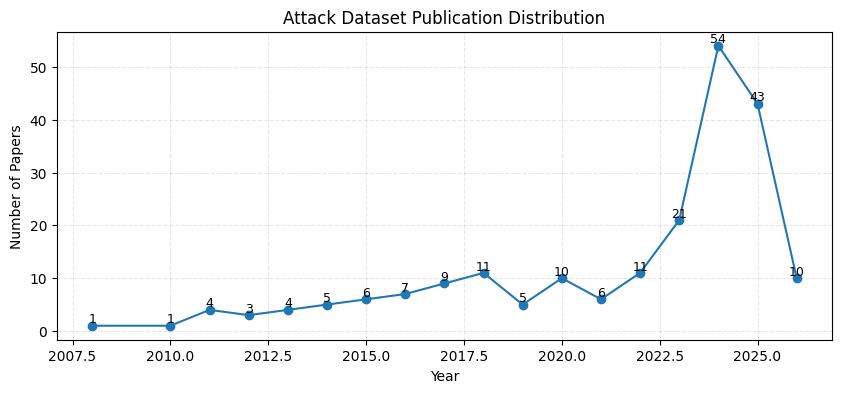

Year
2008     1
2010     1
2011     4
2012     3
2013     4
2014     5
2015     6
2016     7
2017     9
2018    11
2019     5
2020    10
2021     6
2022    11
2023    21
2024    54
2025    43
2026    10
Name: count, dtype: int64


In [18]:
year_counts_attack = df_attack['Year'].value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.plot(year_counts_attack.index,
         year_counts_attack.values,
         marker='o')

# Tambahkan label angka
for x, y in zip(year_counts_attack.index, year_counts_attack.values):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=9)

plt.title("Attack Dataset Publication Distribution")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print(year_counts_attack)

In [26]:
df_attack['clean_text'] = df_attack['Abstract'].apply(preprocess)

vectorizer = TfidfVectorizer(max_df=0.9, min_df=5)
tfidf_matrix = vectorizer.fit_transform(df_attack['clean_text'])

print("TF-IDF Attack shape:", tfidf_matrix.shape)

TF-IDF Attack shape: (211, 873)


In [111]:
lda_attack, vectorizer_attack, doc_topic_attack, count_matrix_attack = run_lda(
    df_attack,
    n_topics=n,
    custom_stopwords=custom_stopwords
)

print_top_words(lda_attack, vectorizer_attack)

Topic 0: user | behavior | network | base | access | method | feature | pattern | learning | time
Topic 1: cloud | attack | computing | access | service | challenge | framework | breach | secure | environment
Topic 2: dataset | detection | cybersecurity | attack | detect | organization | leakage | data | cyber | ai
Topic 3: information | image | employee | breach | potential | loss | user | access | network | password
Topic 4: leakage | information | organization | data | detection | leak | method | detect | protection | sensitive
Topic 5: breach | healthcare | cybersecurity | data | risk | attack | business | patient | cyber | information


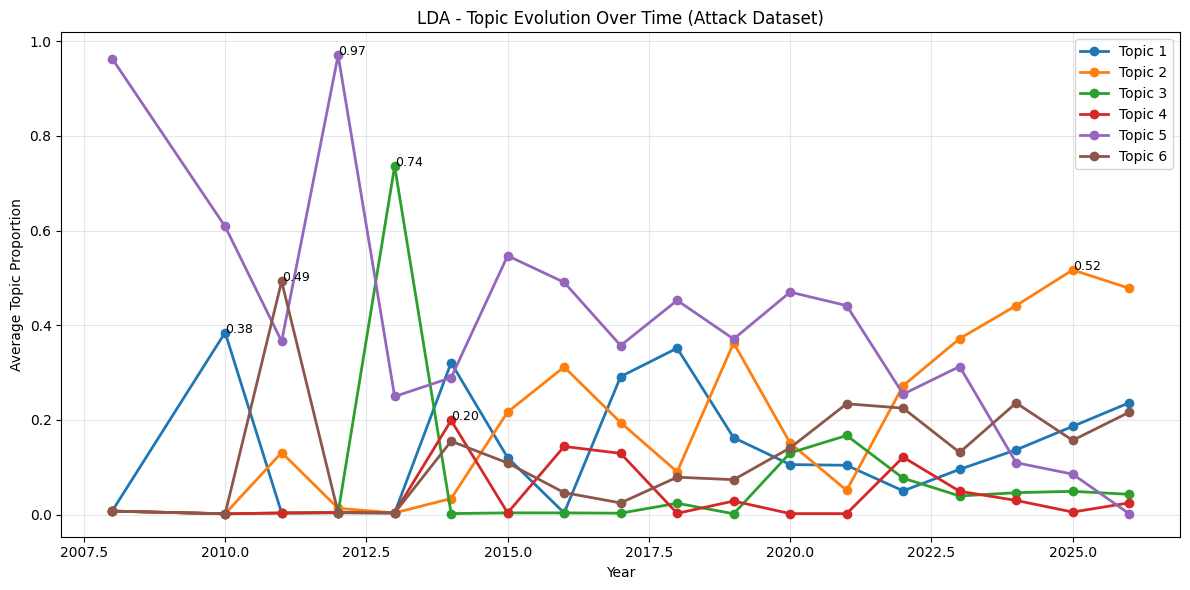

In [135]:
year_topic_attack = plot_topic_evolution(
    lda_model=lda_attack,
    count_matrix=count_matrix_attack,
    df=df_attack,
    label_mode='peak', # 'last' atau 'peak'
    title="LDA - Topic Evolution Over Time (Attack Dataset)",
    save_csv=False,
    csv_name="attack_topic_evolution_raw.csv"
)

In [58]:
print(year_topic_attack)

             0         1         2         3         4         5
Year                                                            
2008  0.007293  0.007323  0.007286  0.007292  0.963491  0.007315
2010  0.384686  0.001643  0.001648  0.001646  0.608735  0.001641
2011  0.003356  0.131016  0.003355  0.003356  0.365987  0.492930
2012  0.004046  0.013282  0.004053  0.004041  0.970472  0.004106
2013  0.003532  0.003516  0.736375  0.003524  0.249530  0.003523
2014  0.320781  0.033883  0.002086  0.198933  0.289261  0.155056
2015  0.120221  0.216656  0.003634  0.003636  0.546809  0.109044
2016  0.003523  0.311853  0.003521  0.143965  0.490727  0.046412
2017  0.291526  0.194438  0.002943  0.129303  0.357148  0.024641
2018  0.351583  0.090361  0.023915  0.002606  0.452555  0.078979
2019  0.162446  0.362676  0.001707  0.028551  0.370924  0.073697
2020  0.105629  0.151011  0.130264  0.002096  0.470056  0.140943
2021  0.104152  0.051137  0.167084  0.001983  0.441551  0.234093
2022  0.050097  0.272408 

In [61]:
agr_attack = calculate_agr(year_topic_attack)
print(agr_attack)

        AGR
0  0.013463
1  0.027700
2  0.002091
3  0.001023
4 -0.056564
5  0.012287


In [64]:
agr_attack_percen = calculate_agr_percent(year_topic_attack)
print(agr_attack_percen)

   AGR_percent
0     1.846001
1     3.782495
2     0.287007
3     0.140301
4    -0.058708
5     1.679609


In [69]:
topic_trend_summary_attack = topic_trend_summary(year_topic_attack)
print(topic_trend_summary_attack)

   Topic  First_Value  Last_Value       AGR  Peak_Year  Peak_Value
0      0     0.007293    0.236165  0.013463       2010    0.384686
1      1     0.007323    0.478226  0.027700       2025    0.516882
2      2     0.007286    0.042834  0.002091       2013    0.736375
3      3     0.007292    0.024683  0.001023       2014    0.198933
4      4     0.963491    0.001899 -0.056564       2012    0.970472
5      5     0.007315    0.216194  0.012287       2011    0.492930


In [119]:
# topic_model_attack, df_attack_topics, yearly_attack, coherence_attack = run_bertopic_pipeline(df_attack)

topic_model_attack, df_attack_topics, yearly_attack, coherence_attack = run_bertopic_pipeline_with_n(
    df_attack,
    n_topics=n
)

trend_attack = compute_topic_trends(yearly_attack)

print("Attack Coherence:", coherence_attack)
print(trend_attack)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Attack Coherence: 0.5016093875997024
   Topic     Slope  R_squared   p_value
0      0  0.009753   0.513785  0.000816
1      1 -0.049427   0.739673  0.000005
2      2  0.014321   0.488016  0.001260
3      3  0.025353   0.569208  0.000297


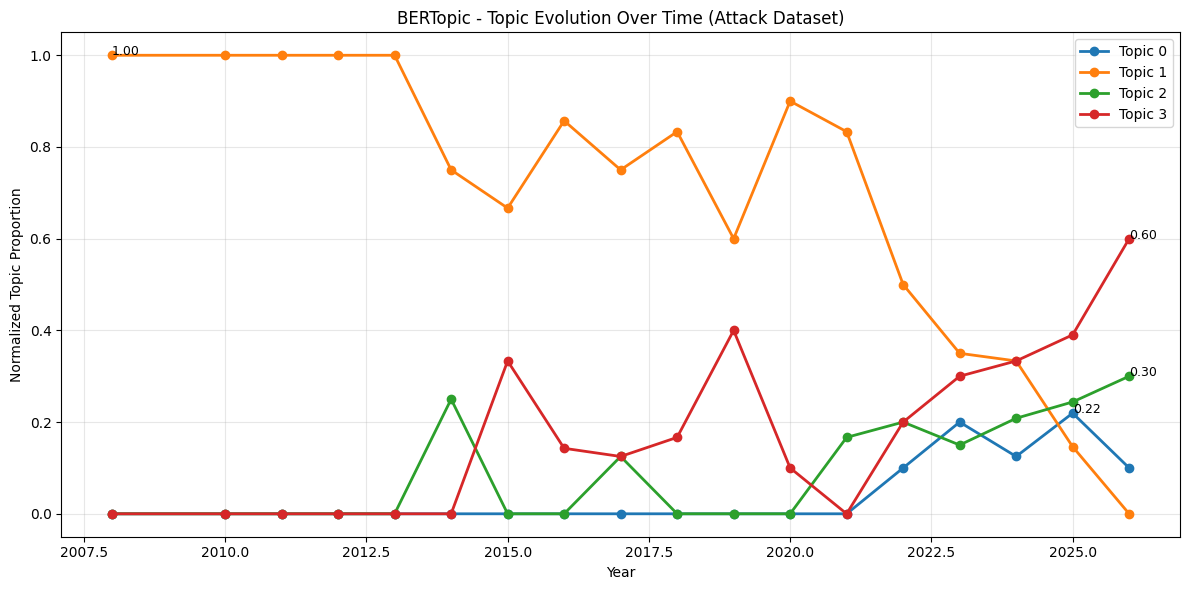

None


In [146]:
pAttack = plot_bertopic_evolution(yearly_attack, title="BERTopic - Topic Evolution Over Time (Attack Dataset)")

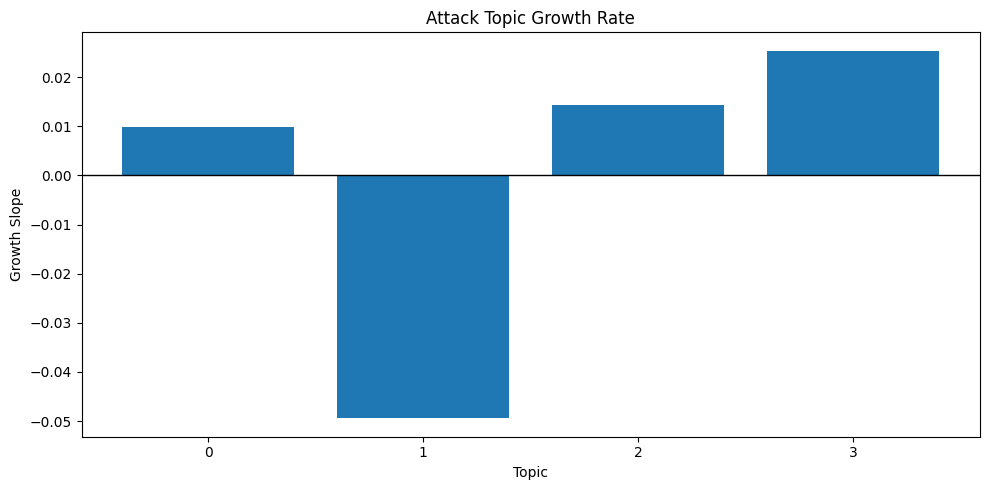

In [121]:
plot_topic_growth(trend_attack, title="Attack Topic Growth Rate")

In [123]:
lda_coherence_attack = calculate_lda_coherence(
    lda_attack,
    vectorizer_attack,
    df_attack["clean_text"].tolist()
)

print("LDA Coherence Attack:", lda_coherence_attack)

LDA Coherence Attack: 0.44117704786351086


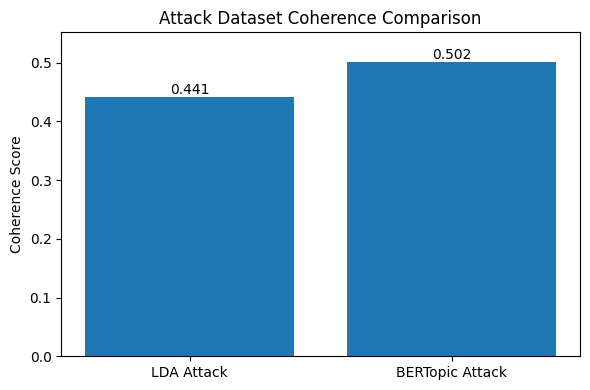

<function plot_coherence_comparison at 0x7d3cdbc06020>


In [147]:
plot_coherence_comparison({
    "LDA Attack": lda_coherence_attack,
    "BERTopic Attack": coherence_attack
}, title="Attack Dataset Coherence Comparison")

In [16]:
# MITIGATION
# MITIGATION
# MITIGATION
# MITIGATION
# MITIGATION
# MITIGATION
# MITIGATION
# MITIGATION
# MITIGATION
# MITIGATION

In [10]:
path_mitigation = "/content/drive/MyDrive/Riset/Review/2738_attack_mitigation.csv"

# Scopus CSV
df_mitigation = pd.read_csv(path_mitigation, sep=",", encoding="utf-8")

# print("Attributes:", list(df_mitigation.columns))
# print(df_mitigation.head(3))
# print(df_mitigation.tail(3))

In [14]:
df_mitigation = clean_dataset(df_mitigation, min_words=50)

Jumlah setelah cleaning: 2690


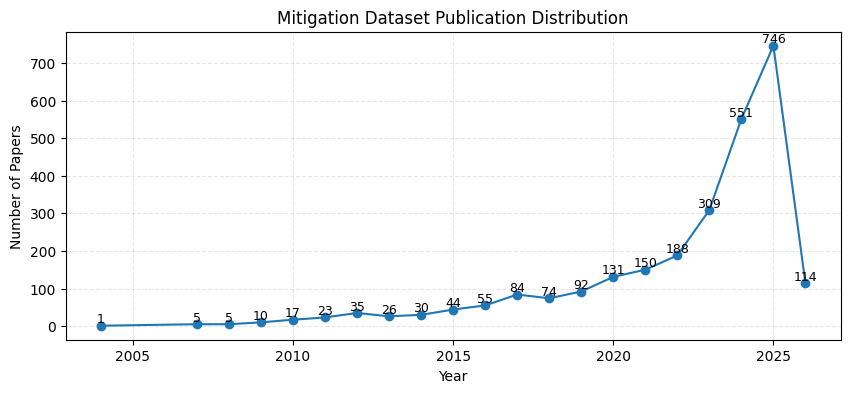

Year
2004      1
2007      5
2008      5
2009     10
2010     17
2011     23
2012     35
2013     26
2014     30
2015     44
2016     55
2017     84
2018     74
2019     92
2020    131
2021    150
2022    188
2023    309
2024    551
2025    746
2026    114
Name: count, dtype: int64


In [20]:
year_counts_mitigation = df_mitigation['Year'].value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.plot(year_counts_mitigation.index,
         year_counts_mitigation.values,
         marker='o')

# Tambahkan label angka
for x, y in zip(year_counts_mitigation.index, year_counts_mitigation.values):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=9)

plt.title("Mitigation Dataset Publication Distribution")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print(year_counts_mitigation)

In [27]:
df_mitigation['clean_text'] = df_mitigation['Abstract'].apply(preprocess)

vectorizer = TfidfVectorizer(max_df=0.9, min_df=5)
tfidf_matrix = vectorizer.fit_transform(df_mitigation['clean_text'])

print("TF-IDF Mitigation shape:", tfidf_matrix.shape)

TF-IDF Mitigation shape: (2690, 3551)


In [112]:
lda_mitigation, vectorizer_mitigation, doc_topic_mitigation, count_matrix_mitigation = run_lda(
    df_mitigation,
    n_topics=n,
    custom_stopwords=custom_stopwords
)

print_top_words(lda_mitigation, vectorizer_mitigation)

Topic 0: network | iot | detection | learning | device | intrusion | attack | base | accuracy | dataset
Topic 1: breach | threat | cybersecurity | risk | cyber | organization | information | data | research | attack
Topic 2: healthcare | blockchain | learning | patient | privacy | technology | data | medical | detection | health
Topic 3: detection | attack | method | base | detect | feature | dataset | result | network | technique
Topic 4: leakage | information | user | data | sensitive | application | base | privacy | detect | analysis
Topic 5: cloud | threat | attack | access | network | service | encryption | computing | secure | environment


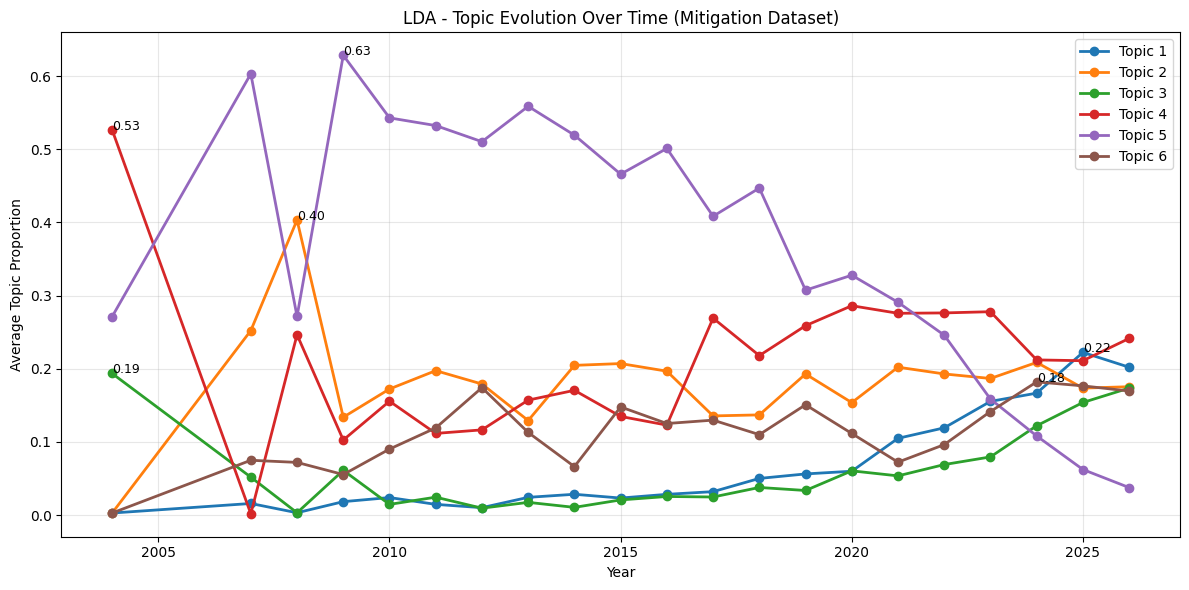

In [137]:
year_topic_mitigation = plot_topic_evolution(
    lda_model=lda_mitigation,
    count_matrix=count_matrix_mitigation,
    df=df_mitigation,
    label_mode='peak',
    title="LDA - Topic Evolution Over Time (Mitigation Dataset)",
    save_csv=False,
    csv_name="mitigation_topic_evolution_raw.csv"
)

In [57]:
print(year_topic_mitigation)

             0         1         2         3         4         5
Year                                                            
2004  0.002849  0.002848  0.193610  0.526579  0.271266  0.002848
2007  0.015903  0.252247  0.051898  0.001808  0.603174  0.074972
2008  0.003230  0.403363  0.003227  0.246544  0.271584  0.072052
2009  0.018406  0.133787  0.061171  0.102644  0.628542  0.055450
2010  0.024017  0.172381  0.014674  0.155694  0.542965  0.090269
2011  0.014693  0.197463  0.024529  0.111677  0.532461  0.119177
2012  0.010193  0.179173  0.009487  0.116524  0.510425  0.174198
2013  0.024307  0.129274  0.017446  0.157190  0.558777  0.113005
2014  0.028488  0.204704  0.010599  0.170570  0.519342  0.066297
2015  0.023327  0.207141  0.020771  0.134874  0.466004  0.147883
2016  0.028408  0.196728  0.025460  0.123023  0.501185  0.125196
2017  0.032089  0.135598  0.024767  0.269240  0.408467  0.129839
2018  0.050156  0.137000  0.037790  0.218027  0.446998  0.110028
2019  0.056298  0.192874 

In [105]:
agr_mitigation = calculate_agr(year_topic_mitigation)
print(agr_mitigation)

        AGR
0  0.009964
1  0.008632
2 -0.000999
3 -0.014254
4 -0.011681
5  0.008337


In [106]:
agr_mitigation_percen = calculate_agr_percent(year_topic_mitigation)
print(agr_mitigation_percen)

   AGR_percent
0     3.497720
1     3.030897
2    -0.005161
3    -0.027069
4    -0.043061
5     2.927069


In [70]:
topic_trend_summary_mitigation = topic_trend_summary(year_topic_mitigation)
print(topic_trend_summary_mitigation)

   Topic  First_Value  Last_Value       AGR  Peak_Year  Peak_Value
0      0     0.002849    0.202137  0.009964       2025    0.222414
1      1     0.002848    0.175493  0.008632       2008    0.403363
2      2     0.193610    0.173625 -0.000999       2004    0.193610
3      3     0.526579    0.241504 -0.014254       2004    0.526579
4      4     0.271266    0.037648 -0.011681       2009    0.628542
5      5     0.002848    0.169593  0.008337       2024    0.182088


In [118]:
# topic_model_mit, df_mit_topics, yearly_mit, coherence_mit = run_bertopic_pipeline(df_mitigation)

topic_model_mit, df_mit_topics, yearly_mit, coherence_mit = run_bertopic_pipeline_with_n(
    df_mitigation,
    n_topics=n
)

trend_mit = compute_topic_trends(yearly_mit)

print("Mitigation Coherence:", coherence_mit)
print(trend_mit)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/85 [00:00<?, ?it/s]

Mitigation Coherence: 0.5246383342918499
   Topic     Slope  R_squared   p_value
0      0 -0.004621   0.360389  0.004011
1      1  0.001564   0.088706  0.189765
2      2  0.001664   0.419392  0.001504
3      3  0.000629   0.305104  0.009418
4      4  0.000764   0.089605  0.187428


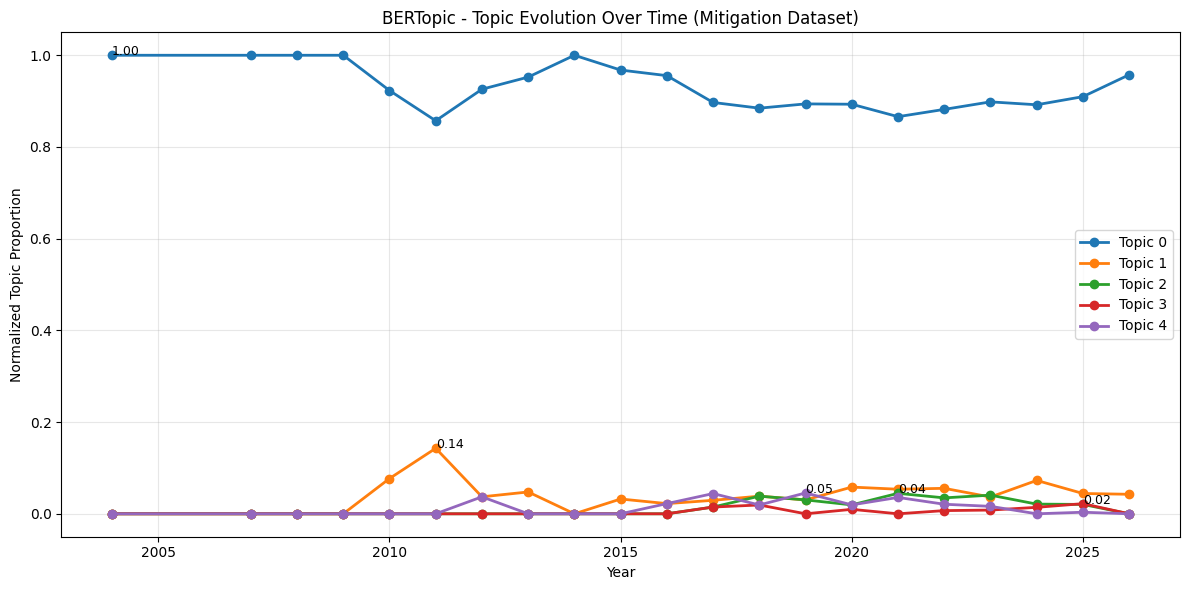

In [138]:
plot_bertopic_evolution(yearly_mit, title="BERTopic - Topic Evolution Over Time (Mitigation Dataset)")

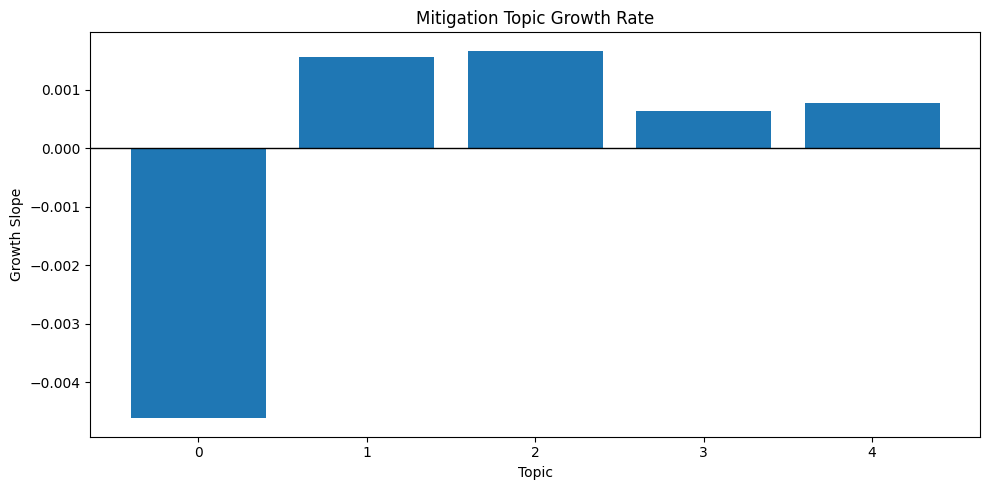

In [127]:
plot_topic_growth(trend_mit, title="Mitigation Topic Growth Rate")

In [129]:
lda_coherence_mitigation = calculate_lda_coherence(
    lda_mitigation,
    vectorizer_mitigation,
    df_mitigation["clean_text"].tolist()
)

print("LDA Coherence Mitigation:", lda_coherence_mitigation)

LDA Coherence Mitigation: 0.5206382937089179


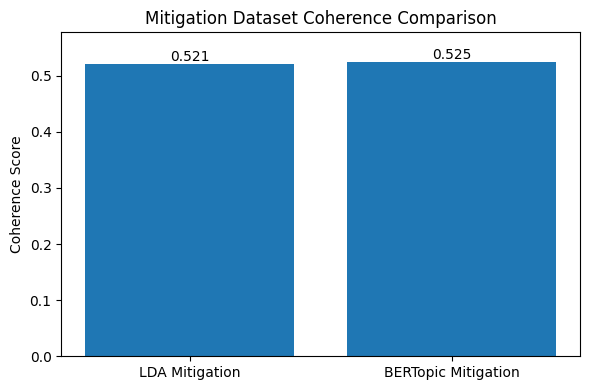

In [131]:
plot_coherence_comparison({
    "LDA Mitigation": lda_coherence_mitigation,
    "BERTopic Mitigation": coherence_mit
}, title="Mitigation Dataset Coherence Comparison")

In [ ]:
# BOTH
# BOTH
# BOTH
# BOTH
# BOTH
# BOTH
# BOTH
# BOTH
# BOTH
# BOTH

In [133]:
df_lda_topics_attack = pd.DataFrame(doc_topic_attack)
df_lda_topics_attack["Year"] = df_attack["Year"].values

yearly_attack_lda = df_lda_topics_attack.groupby("Year").mean()
trend_attack_lda = compute_topic_trends(yearly_attack_lda)


summary_results = []

summary_results.append(
    summarize_model_results(
        "LDA",
        "Attack",
        lda_coherence_attack,
        trend_attack_lda
    )
)

summary_results.append(
    summarize_model_results(
        "BERTopic",
        "Attack",
        coherence_attack,
        trend_attack
    )
)


df_lda_topics_mitigation = pd.DataFrame(doc_topic_mitigation)
df_lda_topics_mitigation["Year"] = df_mitigation["Year"].values

yearly_mitigation_lda = df_lda_topics_mitigation.groupby("Year").mean()
trend_mitigation_lda = compute_topic_trends(yearly_mitigation_lda)

summary_results.append(
    summarize_model_results(
        "LDA",
        "Mitigation",
        lda_coherence_mitigation,
        trend_mitigation_lda
    )
)

summary_results.append(
    summarize_model_results(
        "BERTopic",
        "Mitigation",
        coherence_mit,
        trend_mit
    )
)

comparison_table = pd.DataFrame(summary_results)
comparison_table

,Model,Dataset,Coherence,Avg_Growth,Significant_Topics,Best_Topic,Best_Slope,Best_p_value
0,LDA,Attack,0.4412,0.0,2,1.0,0.026238,0.000049
1,BERTopic,Attack,0.5016,-0.0,4,3.0,0.025353,0.000297
2,LDA,Mitigation,0.5206,-0.0,3,0.0,0.009355,0.000000
3,BERTopic,Mitigation,0.5246,0.0,3,2.0,0.001664,0.001504


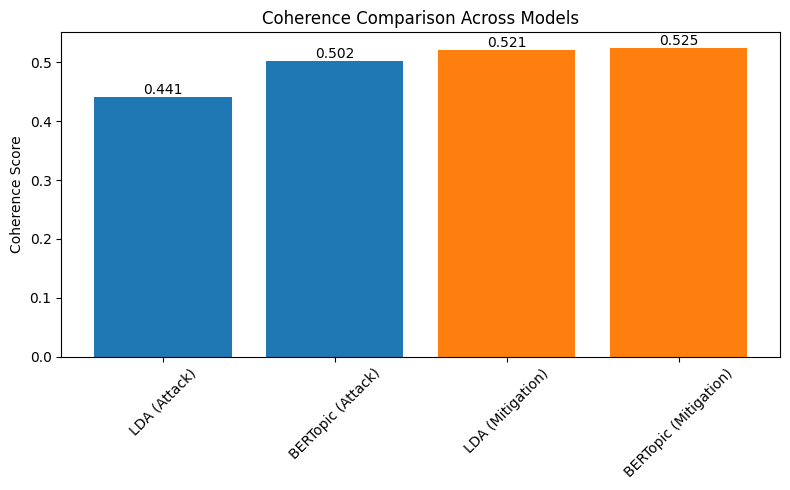

In [142]:
plot_coherence_table(comparison_table)

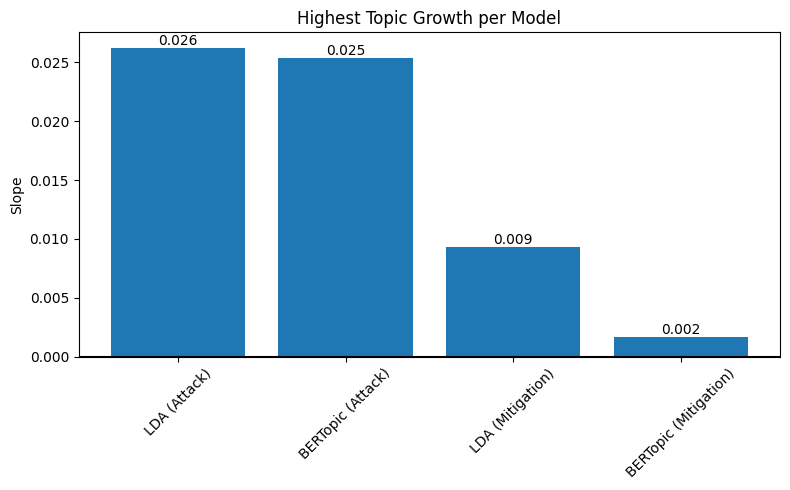

In [144]:
plot_best_growth(comparison_table)

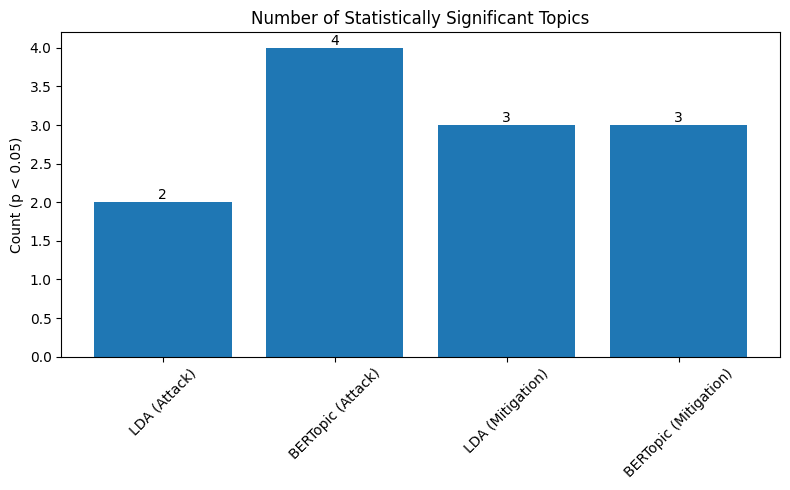

In [145]:
plot_significant_counts(comparison_table)